# Finetuning Qwen3.5

> Originally, adapted from [Qwen3_5_(0_8B)_Vision.ipynb](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(0_8B)_Vision.ipynb#scrollTo=gGFzmplrEy9I)

![Qwen3.5](https://qianwen-res.oss-accelerate.aliyuncs.com/logo_qwen3.5.png)

Qwen3.5 features the following enhancement:

- **Unified Vision-Language Foundation**: Early fusion training on multimodal tokens achieves cross-generational parity with Qwen3 and outperforms Qwen3-VL models across reasoning, coding, agents, and visual understanding benchmarks.
- **Efficient Hybrid Architecture**: Gated Delta Networks combined with sparse Mixture-of-Experts deliver high-throughput inference with minimal latency and cost overhead.
- **Scalable RL Generalization**: Reinforcement learning scaled across million-agent environments with progressively complex task distributions for robust real-world adaptability.
- **Global Linguistic Coverage**: Expanded support to 201 languages and dialects, enabling inclusive, worldwide deployment with nuanced cultural and regional understanding.
- **Next-Generation Training Infrastructure**: Near-100% multimodal training efficiency compared to text-only training and asynchronous RL frameworks supporting massive-scale agent scaffolds and environment orchestration.

In [12]:
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# Force unsloth to be on top
import re
import json
from pathlib import Path
from IPython.display import display

import torch
from PIL import Image
import warnings
from tqdm.auto import tqdm
from trl import SFTConfig, SFTTrainer
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
MODEL_ID = "unsloth/Qwen3.5-9B"
MAX_NEW_TOKENS = 1
MAX_SEQUENCE_LENGTH = 3072
NUM_TRAIN_EPOCHS = 5

# https://unsloth.ai/docs/models/qwen3.5#recommended-settings
ENABLE_THINKING = False
TEMPERATURE = 0.7
MIN_P = 0.01
TOP_P = 0.8
TOP_K = 20

LORA_CHECKPOINT = f"Sci-ImageMiner-{MODEL_ID.split('/')[1]}-LORA-YESNO"

BASE_DIR = Path.cwd().parent
CATEGORIES = ["train", "dev"]

COMPETITION_DATA_DIR = BASE_DIR / "ALD-E-ImageMiner" / "icdar2026-competition-data"

In [3]:
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=False,  # Use 4bit to reduce memory use. False for 16bit LoRA.
    max_seq_length=MAX_SEQUENCE_LENGTH,  # Must match the max_length used during training
    use_gradient_checkpointing="unsloth",  # True or "unsloth" for long context
)

==((====))==  Unsloth 2026.3.3: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 4. Max memory: 47.403 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

<a name="Data"></a>
### 🧪 Data Preparation

To convert our Sci-ImageMiner VQA data into the format required by Qwen2-VL (specifically for use with Unsloth), we need to restructure the data into a "messages" format.

The Qwen/Unsloth format expects a list of conversations where the image and the text prompt are bundled together in the user role, and the ground truth is in the assistant role, as follows:

```python
[
    { "role": "user",
    "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
    },
    { "role": "assistant",
    "content": [{"type": "text",  "text": A} ]
    },
]
```

In [ ]:
PROMPT_YES_NO = """
<image>

[SUMMARY]
{summary}

[TABLE]
{table}

Additional context from the original paper:
{context}

Answer the following scientific figure question by reasoning strictly over the information visible in the figure and the provided context.

Question type: {question_type}
Question: {question}

Strict requirements:
1. Identify the main variables shown (axes, units, and any legend information).
2. Ignore decorative graphics, schematics, arrows, and background elements.
3. Use the provided caption/context only to support interpretation when necessary.
4. Do not speculate or infer beyond what is visually supported.
5. Output plain text only, with no JSON, no code fences, and no surrounding explanatory text.
6. Output your answer STRICTLY as "Yes" or "No" (title case).

Example:
Yes
"""

In [ ]:
def clean_answer(raw_answer: str) -> tuple[str, bool]:
    """
    Cleans the answer and checks if it conforms to the expected type.
    Returns: (cleaned_answer, is_valid_format)
    """
    if not raw_answer or not isinstance(raw_answer, str):
        return "", False

    # Basic cleaning
    cleaned = raw_answer.strip()

    ans_lower = cleaned.lower()
    # Use regex word boundaries (\b) to avoid matching "eyes", "note", "nothing", etc.
    if re.search(r"\byes\b", ans_lower):
        return "Yes", True
    elif re.search(r"\bno\b", ans_lower):
        return "No", True
    return cleaned, False


def convert_to_conversation(prompt: str, image: Image, response: str) -> dict:
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image", "image": image},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": response}]},
    ]
    return {"messages": conversation}


def get_paper_context(json_file_path, window_size=2):
    """
    Finds the parent content.json, extracts the image caption, and
    grabs a sliding window of text blocks (e.g., 2 before, 2 after)
    surrounding the image for highly targeted context.
    """
    # Navigate up from .../16/images/fig_2.json to .../16/content.json
    content_json_path = json_file_path.parent.parent / "content.json"

    assert content_json_path.exists(), f"{content_json_path}"

    # The image path as it appears in content.json (e.g., "images/fig_2.jpg")
    target_img_path = f"images/{json_file_path.stem}.jpg"

    with open(content_json_path, "r", encoding="utf-8") as f:
        content_data = json.load(f)

    img_index = -1
    caption_text = ""

    # Locate the image block in the flat JSON array
    for idx, block in enumerate(content_data):
        if block.get("type") == "image" and block.get("img_path") == target_img_path:
            img_index = idx
            if "img_caption" in block and block["img_caption"]:
                caption_text = " ".join(block["img_caption"])
            break

    if img_index == -1:
        return "Specific context not found for this image."

    # Gather text blocks BEFORE the image
    text_before = []
    for i in range(img_index - 1, -1, -1):
        block = content_data[i]
        if block.get("type") == "text" and "text" in block:
            text_before.insert(0, block["text"])  # Keep chronological order
            if len(text_before) == window_size:
                break

    # Gather text blocks AFTER the image
    text_after = []
    for i in range(img_index + 1, len(content_data)):
        block = content_data[i]
        if block.get("type") == "text" and "text" in block:
            text_after.append(block["text"])
            if len(text_after) == window_size:
                break

    # Assemble the final context string
    context_blocks = []
    if caption_text:
        context_blocks.append(f"Image Caption: {caption_text}")

    context_blocks.extend(text_before)
    context_blocks.extend(text_after)

    return "\n\n".join(context_blocks)


def load_dataset(category: str) -> list[dict]:
    case_dir = COMPETITION_DATA_DIR / category

    samples = []
    json_files = list(case_dir.rglob("*.json"))
    pbar = tqdm(json_files, desc="Processing Subfigures")

    # Simple trackers for your sanity
    valid_count = 0
    invalid_count = 0

    for json_file in pbar:
        fullpath = str(json_file)
        if (
            "content.json" in json_file.name
            or "images" not in fullpath
            or ".vscode" in fullpath
        ):
            continue

        pbar.set_description(f"Processing {json_file.name}")

        with open(json_file, "r") as f:
            data = json.load(f)

        img_path = json_file.with_suffix(".jpg")
        assert img_path.exists(), f"{json_file.name} does not exist"

        # Open the full source image once
        full_img = Image.open(img_path.absolute())
        context = get_paper_context(json_file)

        # Extract bounding box info
        bboxes = data.get("bbox", {})

        # Iterate through subfigures (a, b, etc.) present in the VQA data
        for sub_key, q_list in data.get("vqa", {}).items():
            # Skip if there's no bounding box for this subfigure
            if sub_key not in bboxes:
                warnings.warn(f"Subfigure {sub_key} missing bbox in {json_file}")
                continue

            # Get coordinates and crop
            box = bboxes[sub_key]
            left = box["x"]
            top = box["y"]
            right = left + box["width"]
            bottom = top + box["height"]

            # Create the sub-image crop
            sub_image = full_img.crop((left, top, right, bottom))

            summary = data.get("summarization", {}).get(sub_key, None)
            table = data.get("data_extraction", {}).get(sub_key, None)

            # Process every question associated with this specific sub-figure
            for q_obj in q_list:
                question_text = q_obj.get("question") or q_obj.get("questions")
                question_type = q_obj.get("question_type", "")
                answer_type = q_obj.get("answer_type", "")

                if answer_type != "Yes/No":
                    continue

                human_prompt = PROMPT_YES_NO.format(
                    question=question_text,
                    question_type=question_type,
                    context=context,
                    summary=summary if summary is not None else "N/A",
                    table=table if table is not None else "N/A",
                )

                raw_response = q_obj.get("answer", "")

                # --- APPLY CLEANING HERE ---
                cleaned_response, is_valid = clean_answer(raw_response)

                # Skip invalid formats to keep the fine-tuning dataset pristine
                if not is_valid:
                    invalid_count += 1
                    continue

                valid_count += 1

                # Pass the cropped sub_image and the CLEANED response
                sample = convert_to_conversation(
                    human_prompt, sub_image, cleaned_response
                )
                samples.append(sample)

    return samples, valid_count, invalid_count

Let's convert the dataset into the "correct" format for finetuning:

In [6]:
dataset = []
valid_count = 0
invalid_count = 0

for category in CATEGORIES:
    print(f"\nLoading category: {category}")
    ds, vc, ic = load_dataset(category)

    dataset.extend(ds)
    valid_count += vc
    invalid_count += ic

print("-" * 40)
print("📋 DATASET CREATION SUMMARY")
print(f"Added to dataset (Valid): {valid_count}")
print(f"Skipped (Invalid format): {invalid_count}")
print("-" * 40)


Loading category: train


Processing Subfigures:   0%|          | 0/1301 [00:00<?, ?it/s]

/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure d missing bbox in /home/vsioros/sci-imageminer-2026/ALD-E-ImageMiner/icdar2026-competition-data/train/atomic-layer-etching/experimental-usecase/34/images/fig_1.json
  warnings.warn(f"Subfigure {sub_key} missing bbox in {json_file}")
/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure b missing bbox in /home/vsioros/sci-imageminer-2026/ALD-E-ImageMiner/icdar2026-competition-data/train/atomic-layer-etching/experimental-usecase/34/images/fig_1.json
  warnings.warn(f"Subfigure {sub_key} missing bbox in {json_file}")
/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure c missing bbox in /home/vsioros/sci-imageminer-2026/ALD-E-ImageMiner/icdar2026-competition-data/train/atomic-layer-etching/experimental-usecase/34/images/fig_1.json
  warnings.warn(f"Subfigure {sub_key} missing bbox in {json_file}")
/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure d missing bbox in /home/vsioros/sci-imagemine


Loading category: dev


Processing Subfigures:   0%|          | 0/221 [00:00<?, ?it/s]

----------------------------------------
📋 DATASET CREATION SUMMARY
Added to dataset (Valid): 424
Skipped (Invalid format): 0
----------------------------------------


/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure d missing bbox in /home/vsioros/sci-imageminer-2026/ALD-E-ImageMiner/icdar2026-competition-data/dev/atomic-layer-deposition/simulation-usecase/13/images/fig9.json
  warnings.warn(f"Subfigure {sub_key} missing bbox in {json_file}")
/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure c missing bbox in /home/vsioros/sci-imageminer-2026/ALD-E-ImageMiner/icdar2026-competition-data/dev/atomic-layer-deposition/simulation-usecase/13/images/fig9.json
  warnings.warn(f"Subfigure {sub_key} missing bbox in {json_file}")
/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure d missing bbox in /home/vsioros/sci-imageminer-2026/ALD-E-ImageMiner/icdar2026-competition-data/dev/atomic-layer-deposition/simulation-usecase/13/images/fig_7.json
  warnings.warn(f"Subfigure {sub_key} missing bbox in {json_file}")
/tmp/ipykernel_457329/1530441822.py:134: UserWarning: Subfigure d missing bbox in /home/vsioros/sci-imageminer-202

We look at how the conversations are structured for the first example:

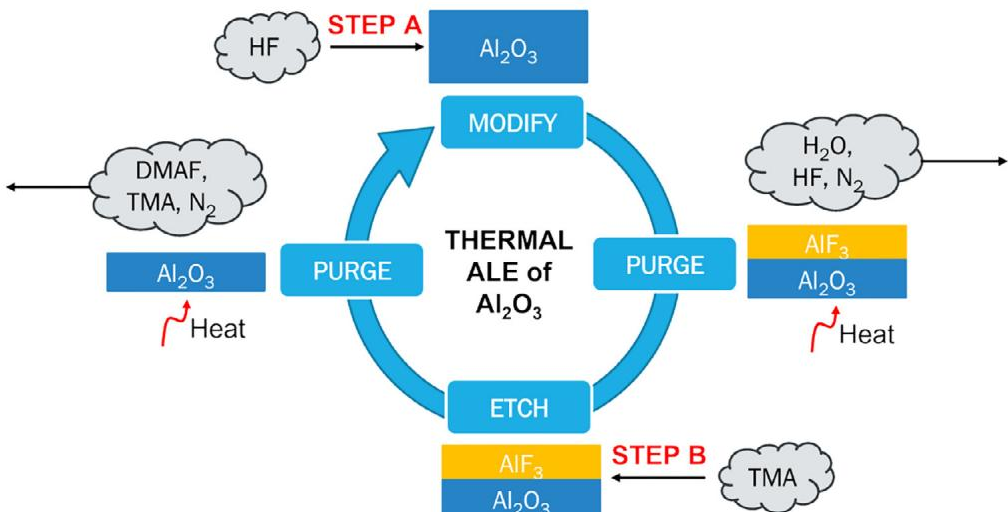

In [7]:
dataset[0]["messages"][0]["content"][1]["image"]

In [8]:
dataset[0]["messages"]

[{'role': 'user',
  'content': [{'type': 'text',
    'text': '\n<image>\n\n[SUMMARY]\nThe figure illustrates a thermal ALE (Atomic Layer Epitaxy) process involving Al2O3. It shows the steps A flourination and B consisting of ligand exchange, including purge, modify, etch, and heat treatments.\n\n[TABLE]\n| Step    | Action   | Reactants       | Products       | Notes                          |\n|---------|----------|-----------------|---------------|--------------------------------|\n| Step A  | Modify   | HF + Al₂O₃     | AlF₃ + Al₂O₃ | Heat applied; HF reacts with Al₂O₃ surface |\n| Purge   | Purge    | DMAF, TMA, N₂  | —             | Removes excess reactants and byproducts |\n| Step B  | Etch     | TMA + AlF₃     | Al₂O₃ exposed | Heat applied; TMA reacts with AlF₃ |\n| Purge   | Purge    | H₂O, HF, N₂    | —             | Clears reaction byproducts     |\n\nAdditional context from the original paper:\nImage Caption: Fig. 1. The thermal ALE cyclical process for  $\\mathrm{Al_2O_3}$

In [9]:
def calculate_token_stats(samples, processor, max_samples=None):
    stats = []

    # Limit samples for speed during exploration
    samples_to_process = samples[:max_samples] if max_samples else samples

    for sample in tqdm(samples_to_process, desc="Calculating token lengths"):
        messages = sample["messages"]

        # 1. Extract the image and assistant text
        image = messages[0]["content"][1]["image"]
        assistant_text = messages[1]["content"][0]["text"]

        # 2. Calculate MAX_NEW_TOKENS (Assistant output only)
        # Access the underlying text tokenizer inside the processor
        assistant_tokens = len(
            processor.tokenizer.encode(assistant_text, add_special_tokens=False)
        )

        # 3. Calculate max_length (Entire sequence: Image + Prompt + Formatting + Answer)
        # Apply the chat template to the full multi-turn conversation
        full_text = processor.apply_chat_template(
            messages, add_generation_prompt=False, tokenize=False
        )

        # Pass the image and the formatted text using keyword arguments
        inputs = processor(
            text=full_text, images=image, add_special_tokens=False, return_tensors="pt"
        )
        total_tokens = inputs["input_ids"].shape[1]

        stats.append(
            {
                "assistant_tokens": assistant_tokens,
                "total_tokens": total_tokens,
                "image_width": image.width,
                "image_height": image.height,
            }
        )

    return pd.DataFrame(stats)

Calculating token lengths:   0%|          | 0/424 [00:00<?, ?it/s]


--- Token Length Statistics ---


,assistant_tokens,total_tokens
count,424.0,424.000000
mean,1.0,1504.120283
std,0.0,347.218277
min,1.0,582.000000
50%,1.0,1492.000000
75%,1.0,1725.000000
90%,1.0,1905.700000
95%,1.0,2085.450000
99%,1.0,2345.160000
max,1.0,3535.000000


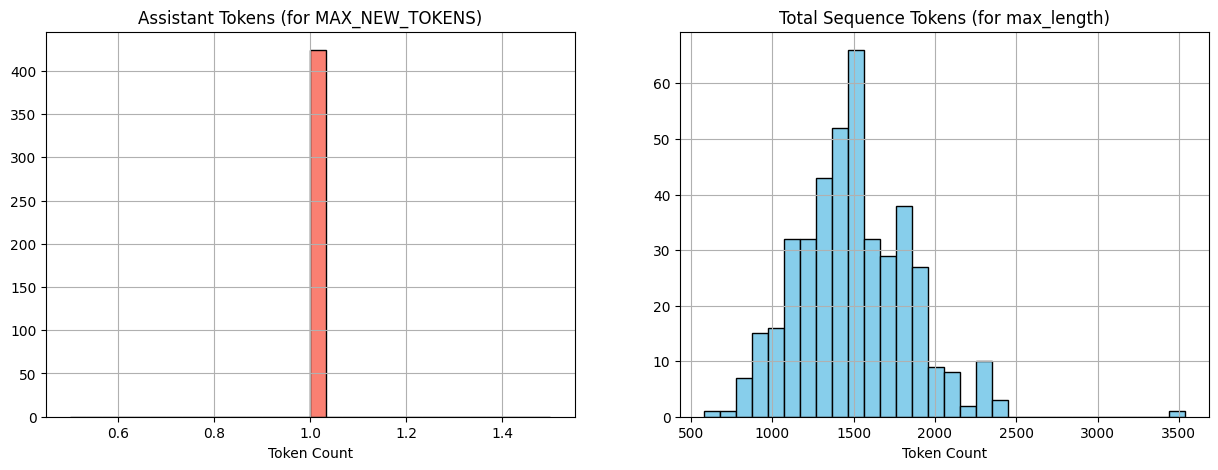

In [10]:
# Run the analysis
df_tokens = calculate_token_stats(dataset, tokenizer)

# Display statistics
print("\n--- Token Length Statistics ---")
display(
    df_tokens[["assistant_tokens", "total_tokens"]].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_tokens["assistant_tokens"].hist(
    bins=30, ax=axes[0], color="salmon", edgecolor="black"
)
axes[0].set_title("Assistant Tokens (for MAX_NEW_TOKENS)")
axes[0].set_xlabel("Token Count")

df_tokens["total_tokens"].hist(bins=30, ax=axes[1], color="skyblue", edgecolor="black")
axes[1].set_title("Total Sequence Tokens (for max_length)")
axes[1].set_xlabel("Token Count")
plt.show()

In [11]:
# 1. Guard against silent truncation (e.g., if max_samples was used in stats)
if len(dataset) != len(df_tokens):
    raise ValueError(
        f"❌ Length mismatch: Dataset has {len(dataset)} samples, but token stats "
        f"have {len(df_tokens)} rows. Ensure you ran calculate_token_stats with max_samples=None."
    )

# 2. Guard against missing or corrupted data
if "total_tokens" not in df_tokens.columns:
    raise KeyError("❌ The DataFrame is missing the required 'total_tokens' column.")

if df_tokens["total_tokens"].isna().any():
    raise ValueError("❌ The 'total_tokens' column contains missing (NaN) values.")

# 3. Perform the actual filtering
original_size = len(dataset)

dataset = [
    sample
    for sample, total_tokens, assistant_tokens in zip(dataset, df_tokens["total_tokens"], df_tokens["assistant_tokens"])
    if total_tokens <= MAX_SEQUENCE_LENGTH and assistant_tokens <= MAX_NEW_TOKENS
]

filtered_size = len(dataset)
dropped_count = original_size - filtered_size

print("-" * 40)
print("🧹 ROBUST TOKEN FILTERING SUMMARY")
print(f"Original size: {original_size}")
print(f"Max Length Allowed: {MAX_SEQUENCE_LENGTH}")
print(f"Kept (Safe): {filtered_size}")
print(f"Dropped (Outliers): {dropped_count}")
print("-" * 40)

----------------------------------------
🧹 ROBUST TOKEN FILTERING SUMMARY
Original size: 424
Max Length Allowed: 3072
Kept (Safe): 423
Dropped (Outliers): 1
----------------------------------------


Calculating token lengths:   0%|          | 0/423 [00:00<?, ?it/s]


--- Token Length Statistics ---


,assistant_tokens,total_tokens
count,423.0,423.000000
mean,1.0,1499.319149
std,0.0,333.240879
min,1.0,582.000000
50%,1.0,1491.000000
75%,1.0,1724.000000
90%,1.0,1905.000000
95%,1.0,2070.600000
99%,1.0,2333.940000
max,1.0,2420.000000


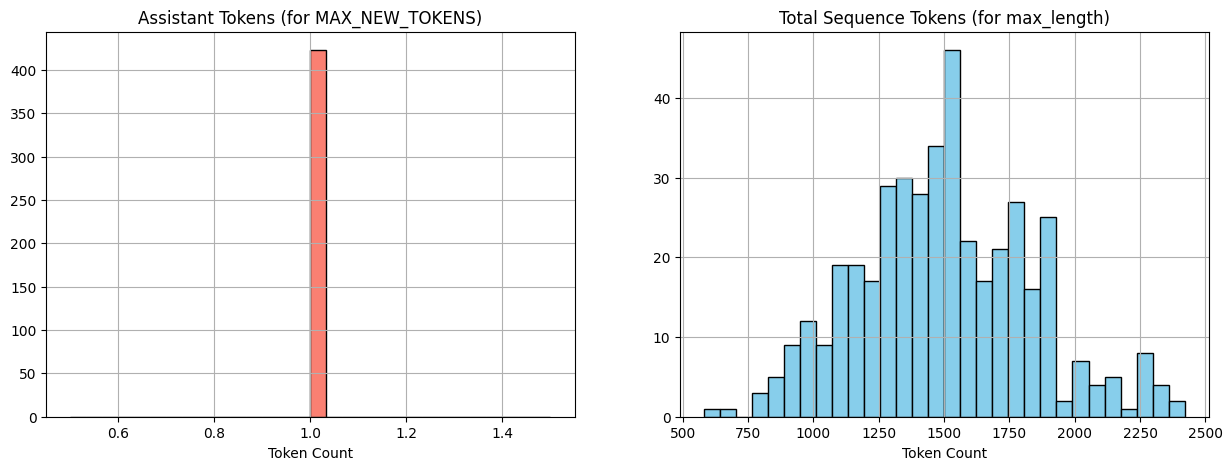

In [13]:
# Run the analysis again on the filtered dataset to confirm
df_tokens = calculate_token_stats(dataset, tokenizer)

# Display statistics
print("\n--- Token Length Statistics ---")
display(
    df_tokens[["assistant_tokens", "total_tokens"]].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_tokens["assistant_tokens"].hist(
    bins=30, ax=axes[0], color="salmon", edgecolor="black"
)
axes[0].set_title("Assistant Tokens (for MAX_NEW_TOKENS)")
axes[0].set_xlabel("Token Count")

df_tokens["total_tokens"].hist(bins=30, ax=axes[1], color="skyblue", edgecolor="black")
axes[1].set_title("Total Sequence Tokens (for max_length)")
axes[1].set_xlabel("Token Count")
plt.show()

In [15]:
print("\n--- Class Imbalance Check & Upsampling ---")

yes_samples = []
no_samples = []

# 1. Separate the dataset into Yes and No categories
for sample in dataset:
    # Extract the assistant's response from the Unsloth/Qwen format
    answer = sample["messages"][1]["content"][0]["text"]
    if answer == "Yes":
        yes_samples.append(sample)
    elif answer == "No":
        no_samples.append(sample)

print(f"Original 'Yes' count: {len(yes_samples)}")
print(f"Original 'No' count: {len(no_samples)}")

# 2. Identify majority and minority classes
if len(yes_samples) > len(no_samples):
    majority_class, minority_class = yes_samples, no_samples
    minority_name = "No"
else:
    majority_class, minority_class = no_samples, yes_samples
    minority_name = "Yes"

imbalance_diff = len(majority_class) - len(minority_class)

# 3. Upsample if there is an imbalance
if imbalance_diff > 0:
    print(
        f"Upsampling minority class ('{minority_name}') by {imbalance_diff} samples..."
    )

    # Randomly sample from the minority class with replacement
    upsampled_additions = random.choices(minority_class, k=imbalance_diff)

    # Rebuild the dataset with balanced classes
    dataset = majority_class + minority_class + upsampled_additions

    # Shuffle to ensure the duplicated examples are distributed evenly
    random.seed(3407)  # using your notebook's random state
    random.shuffle(dataset)

    print(f"New dataset size after upsampling: {len(dataset)}")

    # Verification
    final_yes = sum(
        1 for s in dataset if s["messages"][1]["content"][0]["text"] == "Yes"
    )
    final_no = sum(1 for s in dataset if s["messages"][1]["content"][0]["text"] == "No")
    print(f"Final Count -> Yes: {final_yes} | No: {final_no}")
else:
    print("Classes are already perfectly balanced!")


--- Class Imbalance Check & Upsampling ---
Original 'Yes' count: 310
Original 'No' count: 113
Upsampling minority class ('No') by 197 samples...
New dataset size after upsampling: 620
Final Count -> Yes: 310 | No: 310


<a name="Training"></a>
### 🚀 Training the model

Now let's train our model. We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

We do 60 steps to speed things up, but we can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

> We could also use `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,  # False if not finetuning vision layers
    finetune_language_layers=True,  # False if not finetuning language layers
    finetune_attention_modules=True,  # False if not finetuning attention layers
    finetune_mlp_modules=True,  # False if not finetuning MLP layers
    r=16,  # The larger, the higher the accuracy, but might overfit
    lora_alpha=16,  # Recommended alpha == r at least
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,  # We support rank stabilized LoRA
    loftq_config=None,  # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

In [ ]:
FastVisionModel.for_training(model)  # Enable for training!

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(
        model, tokenizer, max_seq_length=MAX_SEQUENCE_LENGTH, resize="max"
    ),  # https://github.com/unslothai/unsloth/issues/2764
    train_dataset=dataset,
    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_ratio=0.05,
        # max_steps=30,
        num_train_epochs=NUM_TRAIN_EPOCHS,  # Set this instead of max_steps for full training runs
        learning_rate=2e-4,
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.001,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        report_to="none",  # For Weights and Biases
        # You MUST put the below items for vision finetuning:
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_length=MAX_SEQUENCE_LENGTH,
    ),
)

In [ ]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

In [ ]:
trainer_stats = trainer.train()

In [ ]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime'] / 60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

<a name="Saving"></a>
### 💾 Saving, loading finetuned models

To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

> This **ONLY** saves the LoRA adapters, and not the full model.

In [ ]:
model.save_pretrained(LORA_CHECKPOINT)  # Local saving
tokenizer.save_pretrained(LORA_CHECKPOINT)
# model.push_to_hub(f"billsioros/{LORA_CHECKPOINT}", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub(f"billsioros/{LORA_CHECKPOINT}", token = "YOUR_HF_TOKEN") # Online saving